# Gastro-Transformer: Paper Figures

**Paper:** *Gastro-Transformer: Q-Former Cross-Attention Fusion with IC50-Aware Pretraining for Drug Response Prediction*

This notebook generates all 5 publication-quality figures:

| Fig | Title | GPU? |
|-----|-------|------|
| 1 | Architecture diagram | No |
| 2 | t-SNE of Q-Former latent space | Yes (cuda:1) |
| 3 | Generalization hierarchy | No |
| 4 | Component contributions + Transferability | No |
| 5 | Training loss curves (pretraining composite) | No |

In [1]:
"""Cell 1: Imports + publication style configuration."""
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Publication style settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

# Paths
BASE_DIR = Path('..')
FIGURES_DIR = BASE_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

# Color palette
C_BLUE = '#2166ac'
C_RED = '#b2182b'
C_GREY = '#666666'
C_LIGHT_BLUE = '#92c5de'
C_LIGHT_RED = '#f4a582'
C_DARK_BLUE = '#053061'

print(f"Base dir: {BASE_DIR}")
print(f"Figures dir: {FIGURES_DIR}")
print(f"Matplotlib backend: {matplotlib.get_backend()}")

Base dir: ..
Figures dir: ../figures
Matplotlib backend: module://matplotlib_inline.backend_inline


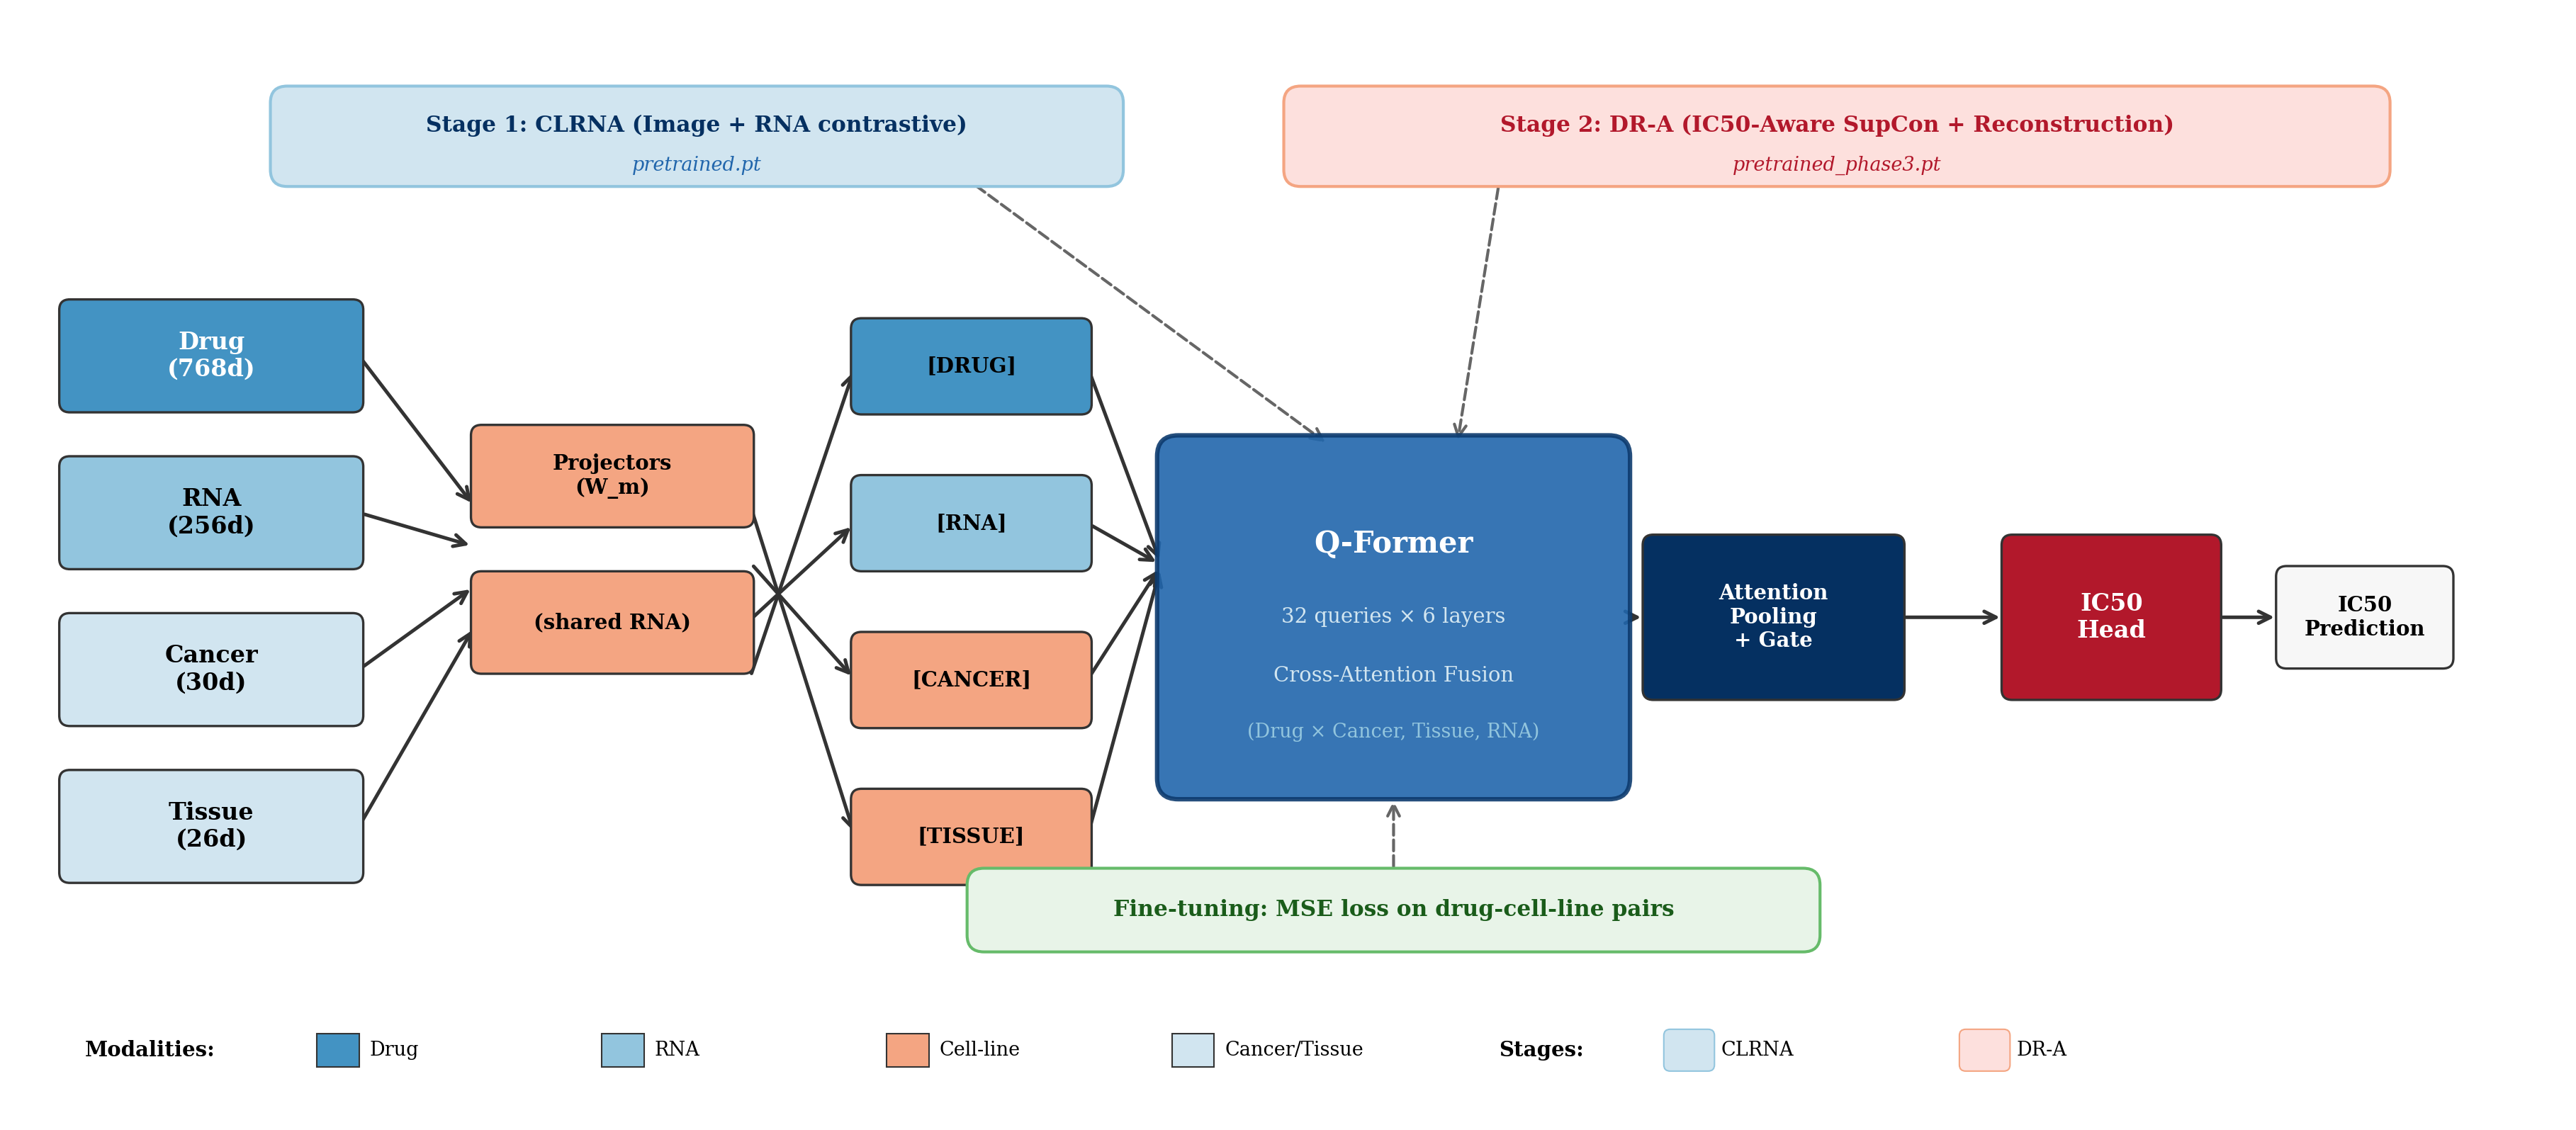

Saved: ../figures/architecture.pdf


In [2]:
"""Cell 2: Figure 1 — Architecture Diagram.

Full pipeline: Drug/RNA/Cancer/Tissue → Projectors → Typed Tokens → Q-Former → Attn Pool → IC50 Head
With pretraining stages (CLRNA + DR-A) annotated above.
"""

def draw_box(ax, x, y, w, h, text, color, textcolor='black', fontsize=8):
    """Draw a rounded box with text."""
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                         boxstyle="round,pad=0.02,rounding_size=0.05",
                         facecolor=color, edgecolor='#333333', linewidth=0.8,
                         zorder=3)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            color=textcolor, fontweight='bold', zorder=4)


def draw_arrow(ax, x1, y1, x2, y2, color='#333333'):
    """Draw an arrow between two points."""
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2),
                zorder=2)


def draw_dashed_arrow(ax, x1, y1, x2, y2, color='#666666'):
    """Draw a dashed arrow."""
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.0,
                                linestyle='dashed', connectionstyle='arc3,rad=0'),
                zorder=2)


fig, ax = plt.subplots(figsize=(12, 5.2))
ax.set_xlim(0, 12)
ax.set_ylim(0, 5.2)
ax.axis('off')

# ── INPUT MODALITY BOXES (left side) ─────────────────────────────────────
input_y_start = 3.6
input_spacing = 0.75

draw_box(ax, 0.9, input_y_start, 1.4, 0.50, 'Drug\n(768d)', '#4393c3', 'white')
draw_box(ax, 0.9, input_y_start - input_spacing, 1.4, 0.50, 'RNA\n(256d)', '#92c5de', 'black')
draw_box(ax, 0.9, input_y_start - 2*input_spacing, 1.4, 0.50, 'Cancer\n(30d)', '#d1e5f0', 'black')
draw_box(ax, 0.9, input_y_start - 3*input_spacing, 1.4, 0.50, 'Tissue\n(26d)', '#d1e5f0', 'black')

# ── PROJECTORS (second column) ────────────────────────────────────────────
proj_x = 2.8
proj_y = input_y_start - 1.5*input_spacing

draw_box(ax, proj_x, proj_y + 0.55, 1.3, 0.45, 'Projectors\n(W_m)', '#f4a582', 'black', fontsize=7)
draw_box(ax, proj_x, proj_y - 0.15, 1.3, 0.45, '(shared RNA)', '#f4a582', 'black', fontsize=7)

# Arrows from inputs to projectors
for dy in [0, -input_spacing, -2*input_spacing, -3*input_spacing]:
    draw_arrow(ax, 1.6, input_y_start + dy, proj_x - 0.65, proj_y + dy * 0.25 + 0.4)

# ── TYPED TOKEN EMBEDDINGS (third column) ────────────────────────────────
token_x = 4.5
token_colors = ['#4393c3', '#92c5de', '#f4a582', '#f4a582']
token_texts = ['[DRUG]', '[RNA]', '[CANCER]', '[TISSUE]']
token_ys = [input_y_start - 0.05, input_y_start - input_spacing - 0.05,
            input_y_start - 2*input_spacing - 0.05, input_y_start - 3*input_spacing - 0.05]

for i, (ty, tc, tt) in enumerate(zip(token_ys, token_colors, token_texts)):
    draw_box(ax, token_x, ty, 1.1, 0.42, tt, tc, 'black', fontsize=7)
    draw_arrow(ax, 3.45, proj_y + (i - 1.5)*0.28, token_x - 0.55, ty)

# ── Q-FORMER (fourth column, center) ─────────────────────────────────────
qformer_x = 6.5
qformer_y = 2.35

qf_box = FancyBboxPatch((qformer_x - 1.1, qformer_y - 0.85), 2.2, 1.7,
                         boxstyle="round,pad=0.02,rounding_size=0.1",
                         facecolor='#2166ac', edgecolor='#0d3b6e', linewidth=1.5,
                         zorder=3, alpha=0.9)
ax.add_patch(qf_box)
ax.text(qformer_x, qformer_y + 0.35, 'Q-Former', ha='center', va='center',
        fontsize=10, color='white', fontweight='bold', zorder=4)
ax.text(qformer_x, qformer_y + 0.0, '32 queries \u00d7 6 layers', ha='center', va='center',
        fontsize=7, color='#d1e5f0', zorder=4)
ax.text(qformer_x, qformer_y - 0.28, 'Cross-Attention Fusion', ha='center', va='center',
        fontsize=7, color='#d1e5f0', zorder=4)
ax.text(qformer_x, qformer_y - 0.55, '(Drug \u00d7 Cancer, Tissue, RNA)', ha='center', va='center',
        fontsize=6.5, color='#92c5de', zorder=4)

# Arrows from tokens to Q-Former
for ty in token_ys:
    draw_arrow(ax, token_x + 0.55, ty, qformer_x - 1.1, qformer_y + 0.25)

# ── ATTENTION POOLING (fifth column) ─────────────────────────────────────
attn_x = 8.3
draw_box(ax, attn_x, qformer_y, 1.2, 0.75, 'Attention\nPooling\n+ Gate', '#053061', 'white', fontsize=7)
draw_arrow(ax, qformer_x + 1.1, qformer_y, attn_x - 0.6, qformer_y)

# ── IC50 HEAD (rightmost) ────────────────────────────────────────────────
head_x = 9.9
draw_box(ax, head_x, qformer_y, 1.0, 0.75, 'IC50\nHead', '#b2182b', 'white', fontsize=8)
draw_arrow(ax, attn_x + 0.6, qformer_y, head_x - 0.5, qformer_y)

# ── OUTPUT ──────────────────────────────────────────────────────────────
out_x = 11.1
draw_box(ax, out_x, qformer_y, 0.8, 0.45, 'IC50\nPrediction', '#f7f7f7', 'black', fontsize=7)
draw_arrow(ax, head_x + 0.5, qformer_y, out_x - 0.4, qformer_y)

# ── PRETRAINING STAGES (above pipeline) ──────────────────────────────────
stage_y = 4.65

# Stage 1: CLRNA
s1_box = FancyBboxPatch((1.2, stage_y - 0.22), 4.0, 0.44,
                         boxstyle="round,pad=0.02,rounding_size=0.08",
                         facecolor='#d1e5f0', edgecolor='#92c5de', linewidth=1.0,
                         zorder=3)
ax.add_patch(s1_box)
ax.text(3.2, stage_y + 0.05, 'Stage 1: CLRNA (Image + RNA contrastive)',
        ha='center', va='center', fontsize=7.5, color='#053061', fontweight='bold', zorder=4)
ax.text(3.2, stage_y - 0.14, 'pretrained.pt', ha='center', va='center',
        fontsize=6.5, color='#2166ac', style='italic', zorder=4)
draw_dashed_arrow(ax, 4.5, stage_y - 0.22, qformer_x - 0.3, qformer_y + 0.82)

# Stage 2: DR-A
s2_box = FancyBboxPatch((6.0, stage_y - 0.22), 5.2, 0.44,
                         boxstyle="round,pad=0.02,rounding_size=0.08",
                         facecolor='#fde0dd', edgecolor='#f4a582', linewidth=1.0,
                         zorder=3)
ax.add_patch(s2_box)
ax.text(8.6, stage_y + 0.05, 'Stage 2: DR-A (IC50-Aware SupCon + Reconstruction)',
        ha='center', va='center', fontsize=7.5, color='#b2182b', fontweight='bold', zorder=4)
ax.text(8.6, stage_y - 0.14, 'pretrained_phase3.pt', ha='center', va='center',
        fontsize=6.5, color='#b2182b', style='italic', zorder=4)
draw_dashed_arrow(ax, 7.0, stage_y - 0.22, qformer_x + 0.3, qformer_y + 0.82)

# ── FINE-TUNING ANNOTATION (below pipeline) ──────────────────────────────
ft_y = 0.95
ft_box = FancyBboxPatch((4.5, ft_y - 0.18), 4.0, 0.36,
                         boxstyle="round,pad=0.02,rounding_size=0.08",
                         facecolor='#e8f4e8', edgecolor='#66bb6a', linewidth=1.0,
                         zorder=3)
ax.add_patch(ft_box)
ax.text(6.5, ft_y, 'Fine-tuning: MSE loss on drug-cell-line pairs',
        ha='center', va='center', fontsize=7.5, color='#1a5c1a', fontweight='bold', zorder=4)
draw_dashed_arrow(ax, 6.5, ft_y + 0.18, qformer_x, qformer_y - 0.85)

# ── LEGEND (bottom) ──────────────────────────────────────────────────────
legend_y = 0.28
ax.text(0.3, legend_y, 'Modalities:', fontsize=7, va='center', fontweight='bold')
legend_items = [
    ('#4393c3', 'Drug'), ('#92c5de', 'RNA'),
    ('#f4a582', 'Cell-line'), ('#d1e5f0', 'Cancer/Tissue'),
]
for i, (color, label) in enumerate(legend_items):
    x_off = 1.4 + i * 1.35
    rect = plt.Rectangle((x_off, legend_y - 0.08), 0.2, 0.16,
                         facecolor=color, edgecolor='#333333', linewidth=0.5)
    ax.add_patch(rect)
    ax.text(x_off + 0.25, legend_y, label, fontsize=6.5, va='center')

ax.text(7.0, legend_y, 'Stages:', fontsize=7, va='center', fontweight='bold')
stage_items = [('#d1e5f0', '#92c5de', 'CLRNA'), ('#fde0dd', '#f4a582', 'DR-A')]
for i, (fc, ec, label) in enumerate(stage_items):
    x_off = 7.8 + i * 1.4
    rect = FancyBboxPatch((x_off, legend_y - 0.08), 0.2, 0.16,
                          boxstyle="round,pad=0.02,rounding_size=0.03",
                          facecolor=fc, edgecolor=ec, linewidth=0.5)
    ax.add_patch(rect)
    ax.text(x_off + 0.25, legend_y, label, fontsize=6.5, va='center')

plt.tight_layout(pad=0.3)
plt.savefig(str(FIGURES_DIR / 'architecture.pdf'))
plt.savefig(str(FIGURES_DIR / 'architecture.png'), dpi=300)
plt.show()
print(f"Saved: {FIGURES_DIR / 'architecture.pdf'}")

Loading data...
Loaded 234 drug embeddings from ../data/drug_embeddings.csv
Loaded 185294 IC50 entries from ../data/ic50_data.csv
After filtering to available drugs: 185294 entries
After removing duplicates: 173942 entries
IC50 values stored as-is (log_transform=False): range [-9.99, 12.90], std=2.774
Number of unique cell-lines: 998
Resolved tissue IDs for 998 unique cell-lines


../gastro_transformer/data.py:582: UserWarning: Found 11352 duplicate drug-cellline pairs. Keeping first occurrence of each pair.
  warnings.warn(


Loaded RNA embeddings for 592 cell-lines
RNA availability: 592/998 cell-lines have RNA, 406 missing

Processing: (a) Random Init
  Using random initialization (no checkpoint)
  Extracted 5000 embeddings of dim 768
  Running t-SNE...

Processing: (b) After CLRNA
  Loading checkpoint: pretrained.pt
  Loaded (52 missing, 9 unexpected keys)
  Extracted 5000 embeddings of dim 768
  Running t-SNE...

Processing: (c) After DR-A
  Loading checkpoint: pretrained_phase3.pt
  Loaded (0 missing, 0 unexpected keys)
  Extracted 5000 embeddings of dim 768
  Running t-SNE...


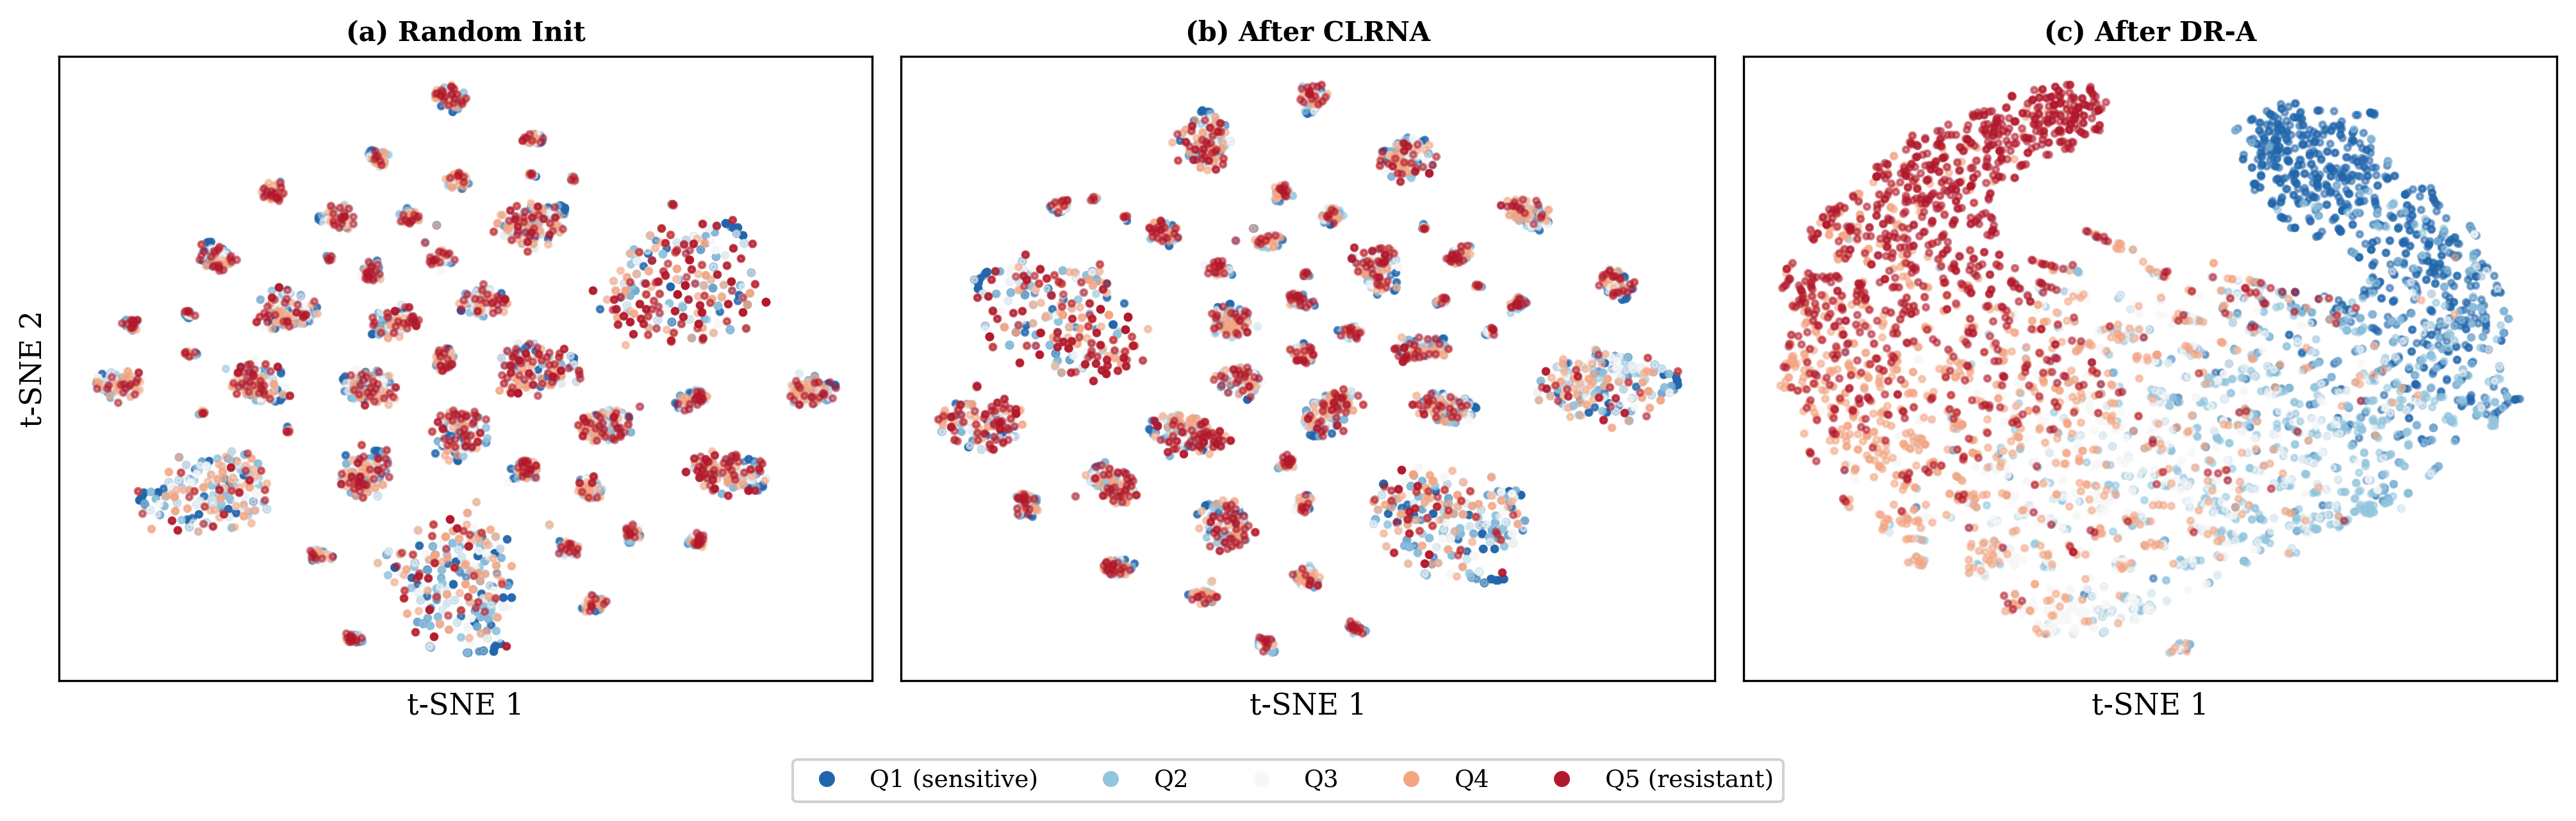


Saved: ../figures/tsne_combined.pdf


In [10]:
"""Cell 3: Figure 2 — t-SNE of Q-Former Latent Space (3-panel comparison).

Compares the Q-Former representation space across pretraining stages:
  (a) Random init — no pretraining
  (b) After CLRNA pretraining (Stage 1)
  (c) After DR-A pretraining (Stage 2)

All panels colored by IC50 quintile to show how pretraining progressively
organizes the latent space by drug sensitivity.

Requires GPU (cuda:1).
"""
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.manifold import TSNE

from gastro_transformer.config import GastroTransformerConfig
from gastro_transformer.model import ModalitySlotQFormer
from gastro_transformer.data import IC50Dataset, DrugEmbeddingDataset
from gastro_transformer.utils import TISSUE_TYPES

DEVICE = torch.device('cuda:1')
MAX_SAMPLES = 5000

# ── Load data (shared across all 3 models) ───────────────────────────────
print("Loading data...")
drug_ds = DrugEmbeddingDataset(str(BASE_DIR / 'data/drug_embeddings.csv'))
ic50_ds = IC50Dataset(
    str(BASE_DIR / 'data/ic50_data.csv'),
    drug_ds,
    rna_csv_path=str(BASE_DIR / 'data/processed/ccle_rna_for_ic50.csv'),
    add_tissue_ids=True,
)

# Same subset for all models (deterministic seed)
rng = np.random.RandomState(42)
indices = rng.choice(len(ic50_ds), min(MAX_SAMPLES, len(ic50_ds)), replace=False)
loader = DataLoader(Subset(ic50_ds, indices), batch_size=256, shuffle=False, num_workers=0)


def extract_embeddings(model, loader, device, max_samples):
    """Extract fused Q-Former embeddings from a model."""
    model.eval()
    embeddings, ic50s, tissue_ids_list = [], [], []
    n = 0
    with torch.no_grad():
        for batch in loader:
            drug_embeds = batch['drug_embed'].to(device)
            cellline_ids = batch['cellline_id'].to(device)
            cancer_type_ids = batch.get('cancer_type_id')
            if cancer_type_ids is not None:
                cancer_type_ids = cancer_type_ids.to(device)
            tissue_ids = batch.get('tissue_id')
            if tissue_ids is not None:
                tissue_ids = tissue_ids.to(device)
            cellline_rna = batch.get('rna_embed')
            if cellline_rna is not None:
                cellline_rna = cellline_rna.to(device)
            rna_available = batch.get('rna_available')
            if rna_available is not None:
                rna_available = rna_available.to(device)

            outputs = model(
                drug_embeds=drug_embeds,
                cellline_ids=cellline_ids,
                cancer_type_ids=cancer_type_ids,
                tissue_ids=tissue_ids,
                cellline_rna_embeds=cellline_rna,
                rna_available=rna_available,
            )

            embeddings.append(outputs['fused_embedding'].cpu().numpy())
            ic50s.extend(batch['ic50'].numpy())
            if tissue_ids is not None:
                tissue_ids_list.extend(tissue_ids.cpu().numpy())

            n += len(batch['ic50'])
            if n >= max_samples:
                break

    embeddings = np.concatenate(embeddings)[:max_samples]
    ic50s = np.array(ic50s)[:max_samples]
    tissue_ids_arr = np.array(tissue_ids_list)[:max_samples] if tissue_ids_list else None
    return embeddings, ic50s, tissue_ids_arr


def create_model():
    """Create a fresh model instance with standard config."""
    config = GastroTransformerConfig()
    config.use_multitoken_cellline = True
    config.use_qformer_for_ic50 = True
    config.use_ic50_attn_pool = True
    config.num_celllines = len(ic50_ds.cellline_to_idx)
    config.num_query_tokens = 32
    config.qformer_layers = 6
    return ModalitySlotQFormer(config)


# ── Define the 3 checkpoints ─────────────────────────────────────────────
checkpoints = [
    ('(a) Random Init', None),
    ('(b) After CLRNA', str(BASE_DIR / 'saved_checkpoints/pretrained_clrna.pt')),
    ('(c) After DR-A',  str(BASE_DIR / 'saved_checkpoints/pretrained_dra.pt')),
]

all_coords = []
ic50s_shared = None

for title, ckpt_path in checkpoints:
    print(f"\n{'='*50}")
    print(f"Processing: {title}")

    model = create_model().to(DEVICE)

    if ckpt_path is not None:
        print(f"  Loading checkpoint: {Path(ckpt_path).name}")
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        state_dict = ckpt.get('model_state_dict', ckpt)
        missing, unexpected = model.load_state_dict(state_dict, strict=False)
        print(f"  Loaded ({len(missing)} missing, {len(unexpected)} unexpected keys)")
    else:
        print("  Using random initialization (no checkpoint)")

    embeddings, ic50s, tissue_ids_arr = extract_embeddings(model, loader, DEVICE, MAX_SAMPLES)
    print(f"  Extracted {len(embeddings)} embeddings of dim {embeddings.shape[1]}")

    if ic50s_shared is None:
        ic50s_shared = ic50s  # same data order for all models

    print(f"  Running t-SNE...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
    coords = tsne.fit_transform(embeddings)
    all_coords.append(coords)

    # Free GPU memory between models
    del model, embeddings
    torch.cuda.empty_cache()

# ── Compute IC50 quintiles (shared) ──────────────────────────────────────
quintiles = np.percentile(ic50s_shared, [20, 40, 60, 80])
ic50_bins = np.digitize(ic50s_shared, quintiles)

# ── Plot 3-panel figure ──────────────────────────────────────────────────
colors_q = ['#2166ac', '#92c5de', '#f7f7f7', '#f4a582', '#b2182b']
labels_q = ['Q1 (sensitive)', 'Q2', 'Q3', 'Q4', 'Q5 (resistant)']
panel_labels = ['(a)', '(b)', '(c)']

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

for ax_idx, (coords, (title, _)) in enumerate(zip(all_coords, checkpoints)):
    ax = axes[ax_idx]
    for q in range(5):
        mask = ic50_bins == q
        ax.scatter(coords[mask, 0], coords[mask, 1], c=colors_q[q], s=5, alpha=0.5,
                   label=labels_q[q] if ax_idx == 0 else None, rasterized=True)

    ax.set_xlabel('t-SNE 1')
    if ax_idx == 0:
        ax.set_ylabel('t-SNE 2')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)

# Shared legend below the figure
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=7)
           for c in colors_q]
fig.legend(handles, labels_q, loc='lower center', ncol=5, fontsize=9,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(str(FIGURES_DIR / 'tsne_combined.pdf'))
plt.savefig(str(FIGURES_DIR / 'tsne_combined.png'))
plt.show()
print(f"\nSaved: {FIGURES_DIR / 'tsne_combined.pdf'}")

# Clean up
del all_coords
torch.cuda.empty_cache()

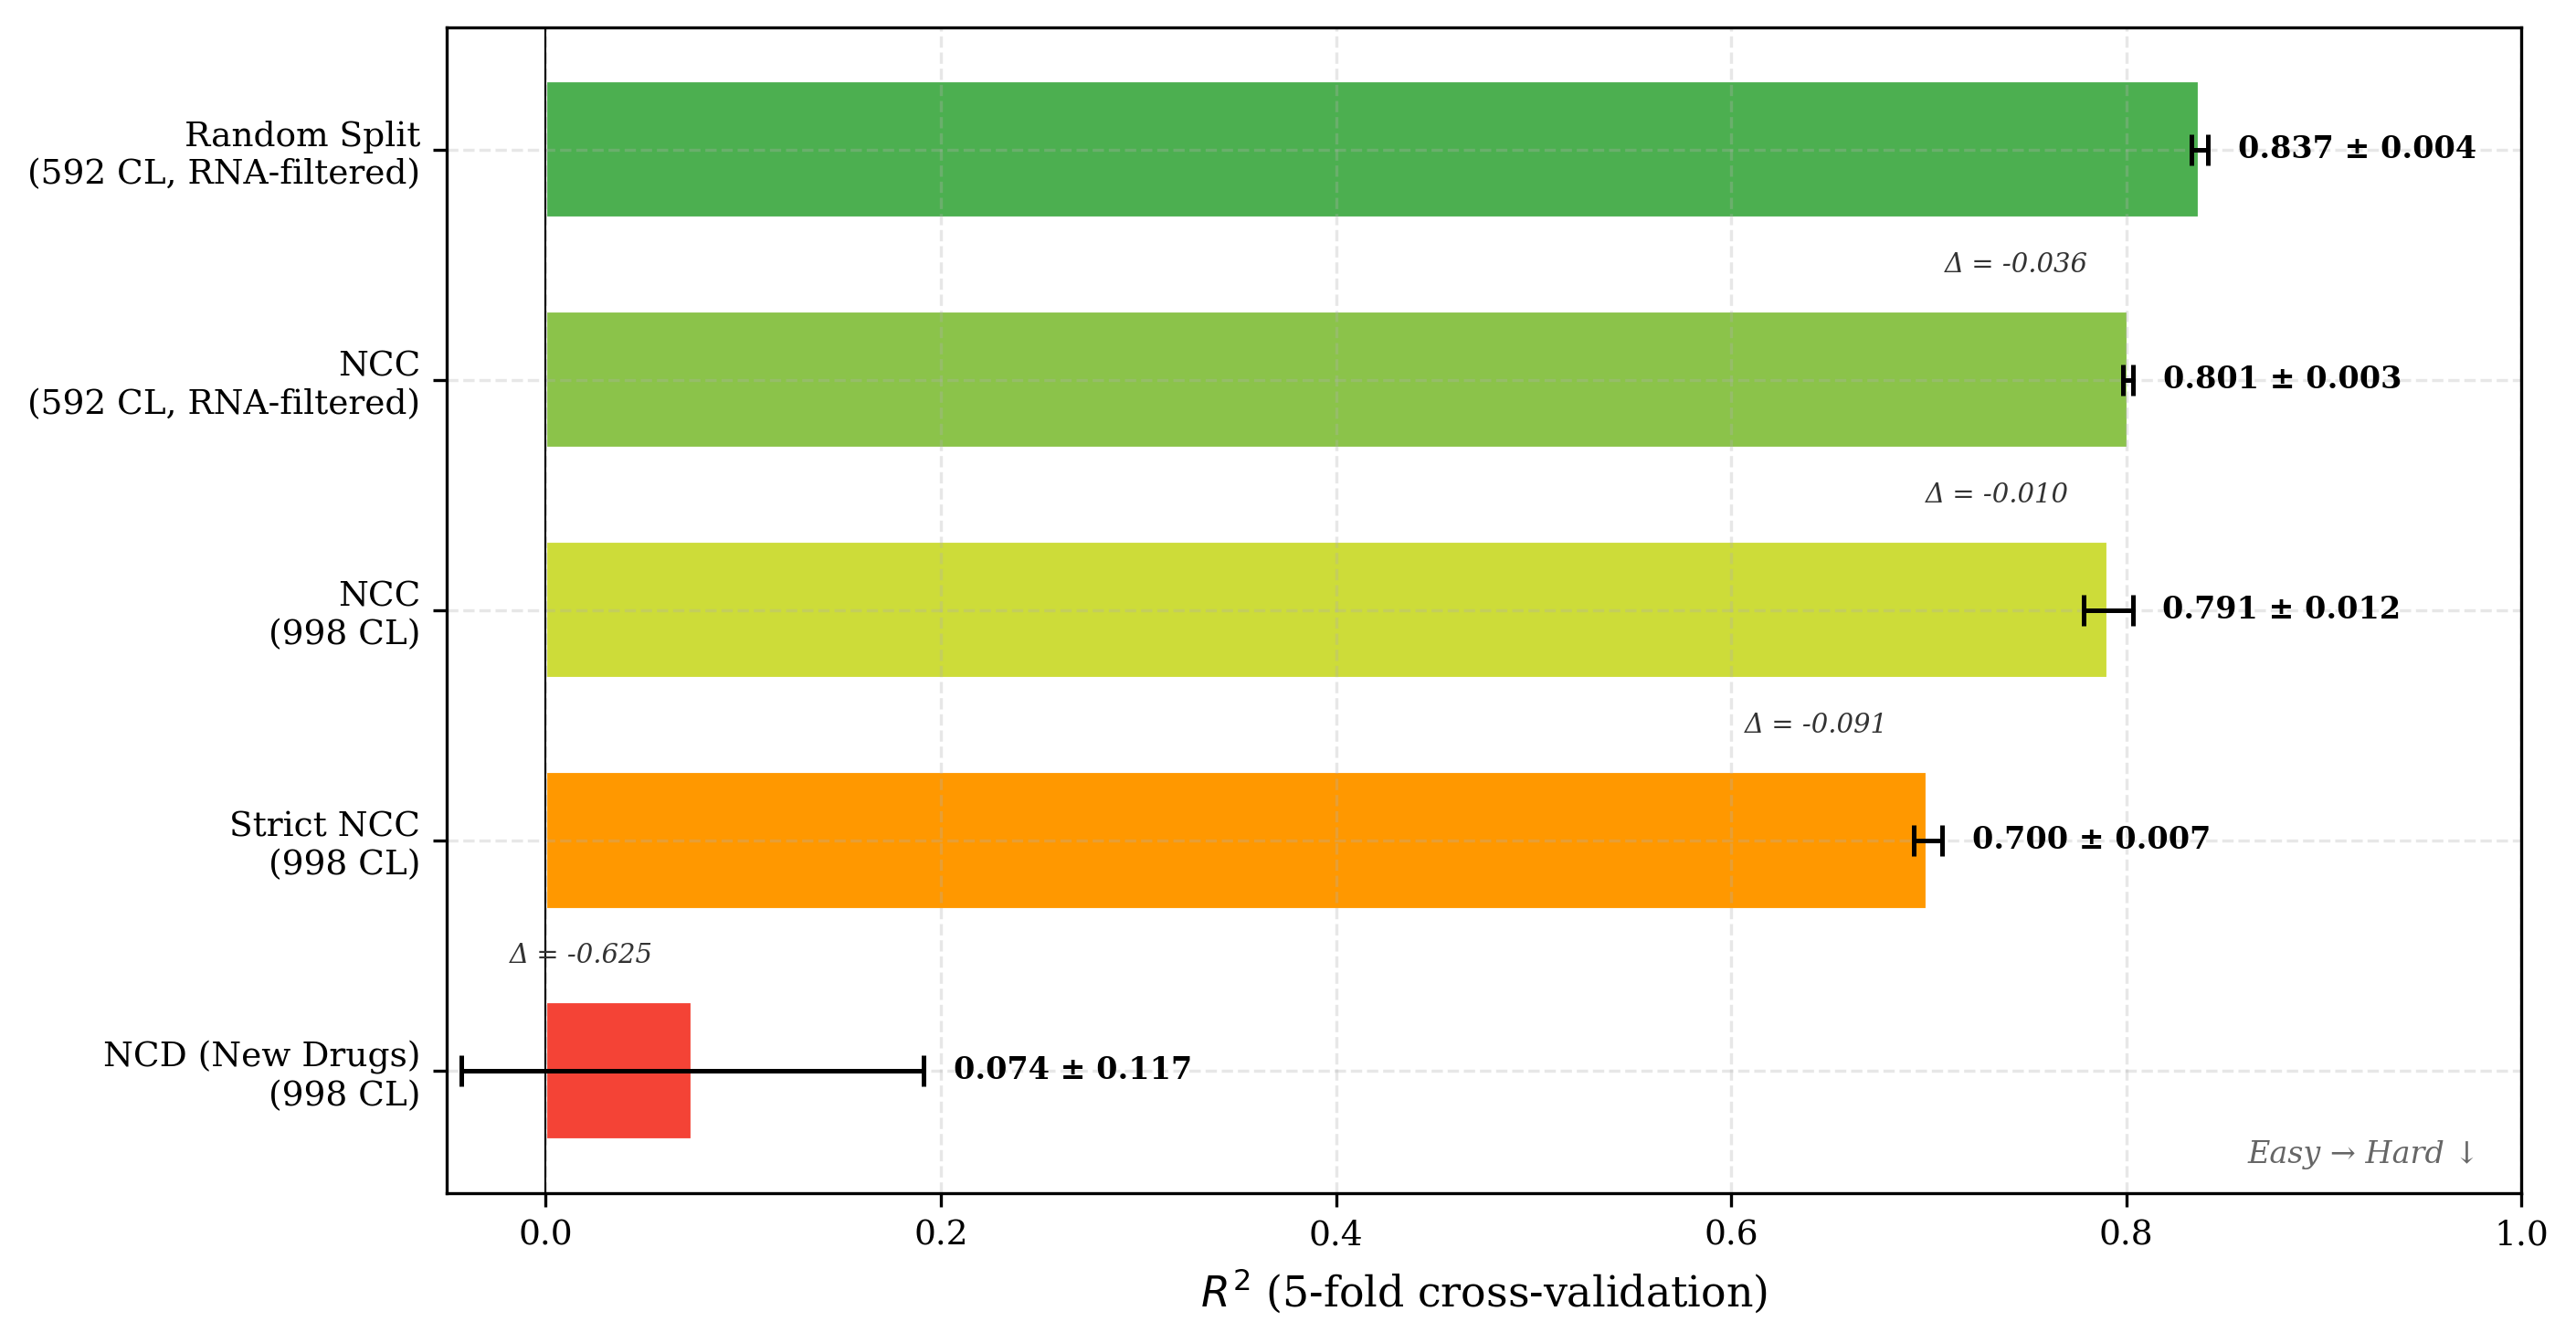

Saved: ../figures/generalization_hierarchy.pdf


In [14]:
"""Cell 4: Figure 3 — Generalization Hierarchy.

Horizontal bar chart showing model performance across increasingly strict
evaluation protocols (DR-A without ssGSEA):
  Random Split (592 CL) → NCC (592 CL) → NCC (998 CL) → Leak-free NCC → NCD

Color gradient: green (easy) → red (hard). Delta annotations between bars.
"""

# Load results from 5 reports
with open(BASE_DIR / 'reports/random_split_5fold_rnafiltered/random_split_rnafiltered_results.json') as f:
    random_data = json.load(f)

with open(BASE_DIR / 'reports/literature_comparison_5fold/literature_results.json') as f:
    ncc_rnafiltered_data = json.load(f)

with open(BASE_DIR / 'reports/5fold_ncc_ablation/ablation_results.json') as f:
    ncc_998_data = json.load(f)

with open(BASE_DIR / 'reports/ncc_leakfree_5fold/ncc_leakfree_results.json') as f:
    ncc_leakfree_data = json.load(f)

with open(BASE_DIR / 'reports/ncdrug_leakfree_5fold/ncd_results.json') as f:
    ncd_data = json.load(f)

# Extract R² mean ± std for each benchmark
benchmarks = [
    ('Random Split\n(592 CL, RNA-filtered)',
     random_data['phase3_pretrained']['average']['r2'],
     random_data['phase3_pretrained']['average']['r2_std']),
    ('NCC\n(592 CL, RNA-filtered)',
     ncc_rnafiltered_data['qformer_phase3_pretrained']['average']['r2'],
     ncc_rnafiltered_data['qformer_phase3_pretrained']['average']['r2_std']),
    ('NCC\n(998 CL)',
     ncc_998_data['multitoken_dra']['average']['r2'],
     ncc_998_data['multitoken_dra']['average']['r2_std']),
    ('Strict NCC\n(998 CL)',
     ncc_leakfree_data['summary']['r2'],
     ncc_leakfree_data['summary']['r2_std']),
    ('NCD (New Drugs)\n(998 CL)',
     ncd_data['summary']['r2'],
     ncd_data['summary']['r2_std']),
]

labels = [b[0] for b in benchmarks]
r2_means = [b[1] for b in benchmarks]
r2_stds = [b[2] for b in benchmarks]

# Color gradient: green (easy) → orange → red (hard)
bar_colors = ['#4caf50', '#8bc34a', '#cddc39', '#ff9800', '#f44336']

fig, ax = plt.subplots(figsize=(9.5, 5.0))

y_pos = range(len(labels))
bars = ax.barh(y_pos, r2_means, xerr=r2_stds, color=bar_colors,
               edgecolor='white', height=0.6, capsize=4,
               error_kw={'linewidth': 1.2, 'capthick': 1.2})

# Value labels
for i, (val, std) in enumerate(zip(r2_means, r2_stds)):
    ax.text(val + std + 0.015, i, f'{val:.3f} \u00b1 {std:.3f}',
            va='center', fontsize=8, fontweight='bold')

# Delta annotations between consecutive bars
for i in range(1, len(r2_means)):
    delta = r2_means[i] - r2_means[i-1]
    mid_y = (i + i - 1) / 2
    ax.annotate(f'\u0394 = {delta:+.3f}',
                xy=(min(r2_means[i], r2_means[i-1]) - 0.02, mid_y),
                fontsize=7, color='#333333', ha='right', va='center',
                fontstyle='italic')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('$R^2$ (5-fold cross-validation)')
# ax.set_title('Generalization Hierarchy: Increasingly Strict Evaluation', fontweight='bold')
ax.set_xlim(-0.05, 1.0)
ax.invert_yaxis()  # Easiest at top
ax.axvline(x=0, color='black', linewidth=0.5)

# Difficulty annotation
ax.text(0.98, 0.02, 'Easy \u2192 Hard \u2193', transform=ax.transAxes,
        fontsize=8, ha='right', va='bottom', color='#666666', fontstyle='italic')

plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'generalization_hierarchy.pdf'))
plt.savefig(str(FIGURES_DIR / 'generalization_hierarchy.png'))
plt.show()
print(f"Saved: {FIGURES_DIR / 'generalization_hierarchy.pdf'}")

/tmp/ipykernel_3728152/1830329049.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


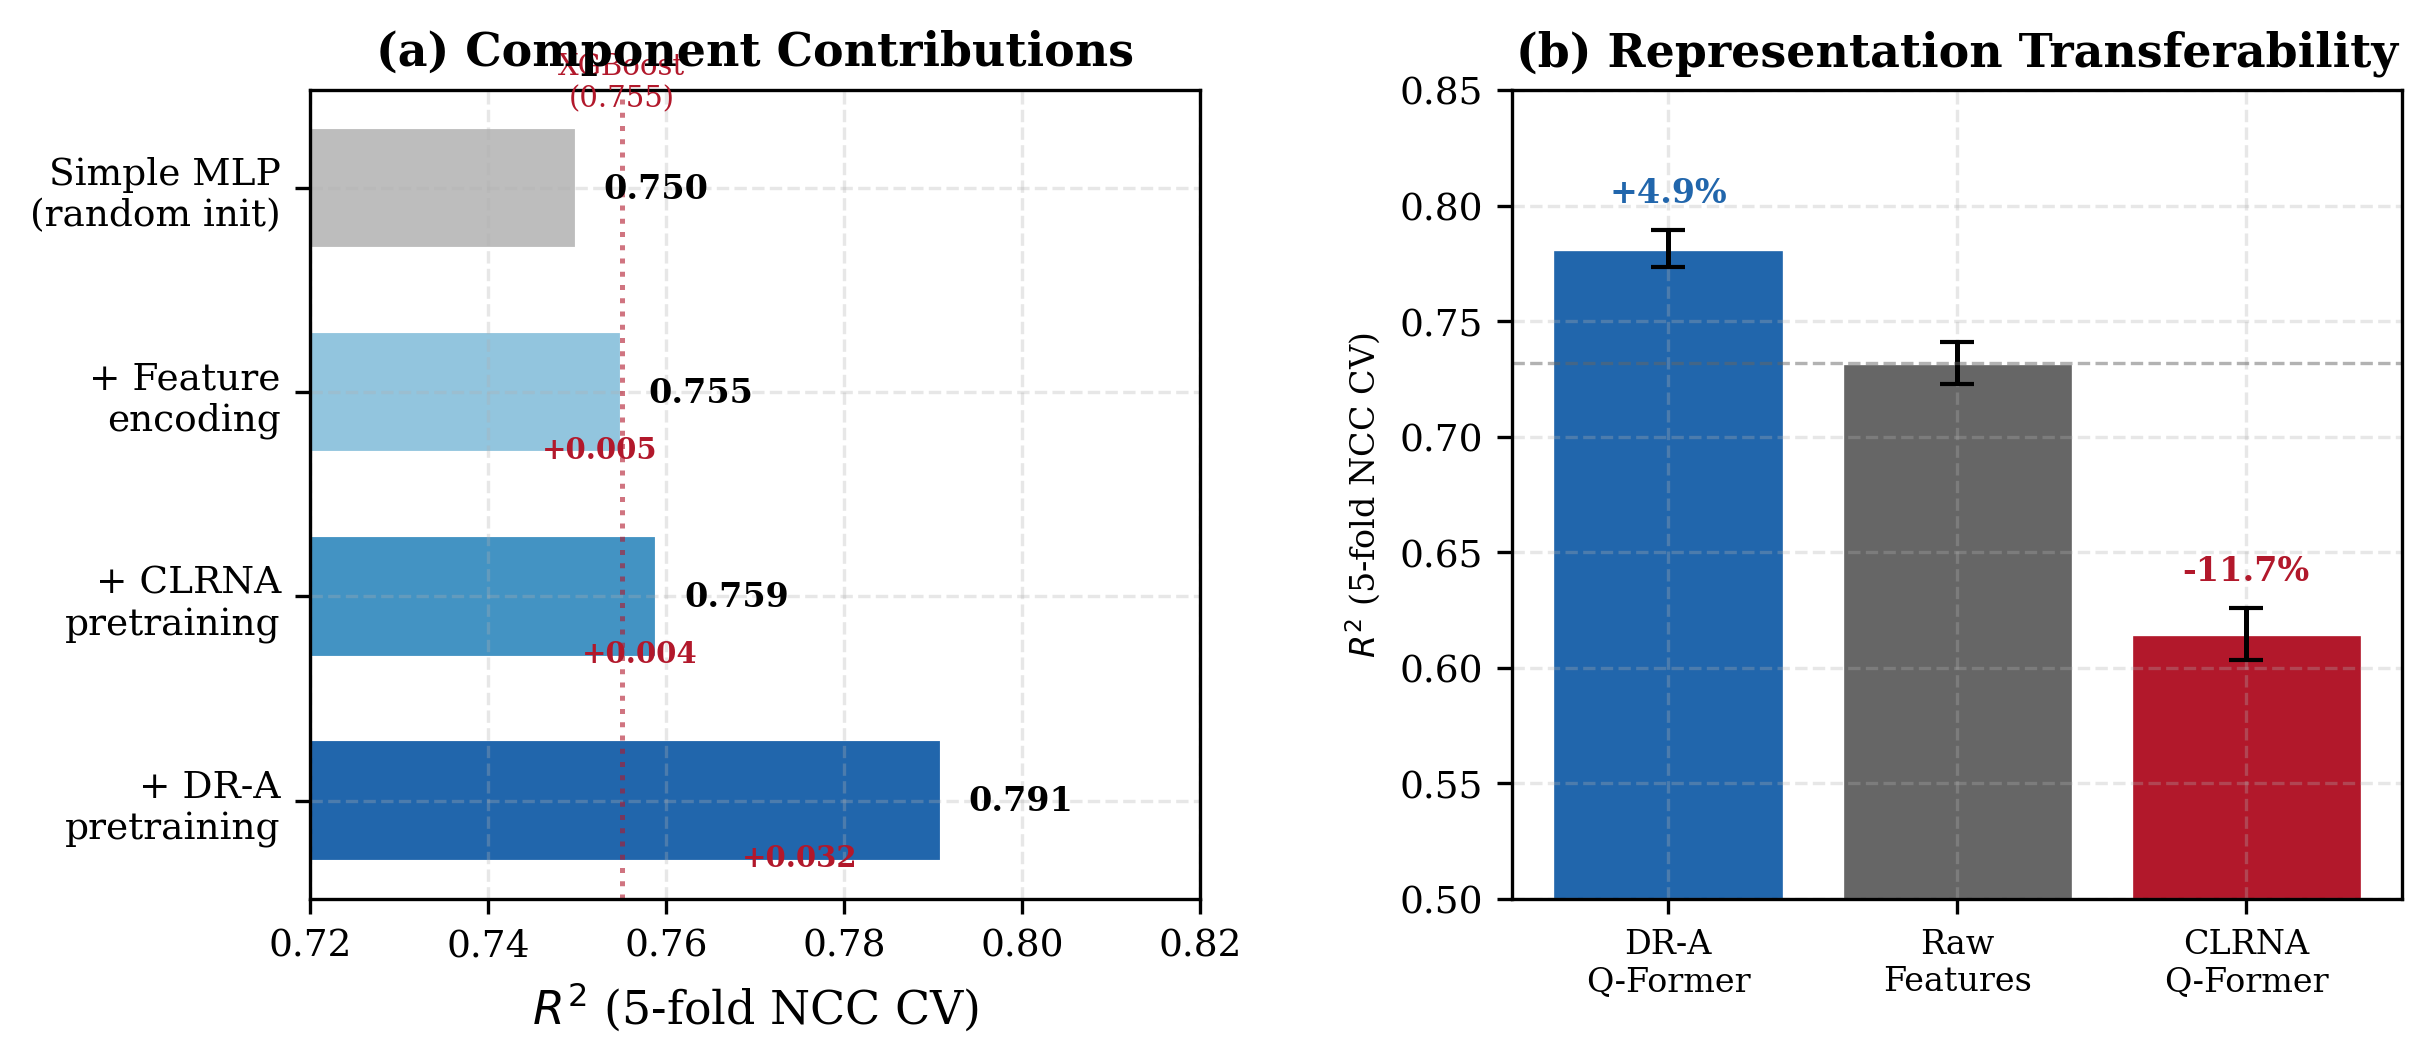

Saved: ../figures/figure4_components_transferability.pdf


In [5]:
"""Cell 5: Figure 4 — Component Contributions + Transferability (2-panel).

Panel (a): Component contributions (MLP → +Q-Former → +CLRNA → +DR-A)
Panel (b): XGBoost on frozen features (DR-A vs Raw vs CLRNA)
"""

# Load transferability data
with open(BASE_DIR / 'reports/qformer_query_clrna_vs_dra/clrna_vs_dra_qformer_results.json') as f:
    tdata = json.load(f)

fig = plt.figure(figsize=(9, 3.5))
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# ── Panel (a): Component contributions ───────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

components = [
    ('Simple MLP\n(random init)', 0.750),
    ('+ Feature\nencoding', 0.755),
    ('+ CLRNA\npretraining', 0.759),
    ('+ DR-A\npretraining', 0.791),
]
r2_values = [c[1] for c in components]
deltas = [0, 0.005, 0.004, 0.032]
comp_labels = [c[0] for c in components]
comp_colors = ['#bdbdbd', '#92c5de', '#4393c3', '#2166ac']

bars = ax1.barh(range(len(comp_labels)), r2_values, color=comp_colors,
               edgecolor='white', height=0.6)
for i, (val, delta) in enumerate(zip(r2_values, deltas)):
    ax1.text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=8, fontweight='bold')
    if delta > 0:
        ax1.text(val - delta/2, i + 0.35, f'+{delta:.3f}', va='bottom', ha='center',
                fontsize=7, color=C_RED, fontweight='bold')

ax1.set_yticks(range(len(comp_labels)))
ax1.set_yticklabels(comp_labels)
ax1.set_xlabel('$R^2$ (5-fold NCC CV)')
ax1.set_title('(a) Component Contributions', fontweight='bold')
ax1.set_xlim(0.72, 0.82)
ax1.invert_yaxis()
ax1.axvline(x=0.755, color=C_RED, linestyle=':', linewidth=1.2, alpha=0.6)
ax1.text(0.755, -0.4, 'XGBoost\n(0.755)', fontsize=7, ha='center', color=C_RED)

# ── Panel (b): Transferability ───────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

tmodels = [
    ('DR-A\nQ-Former', tdata['dra_features']['aggregated']['r2']['mean'],
     tdata['dra_features']['aggregated']['r2']['std'], C_BLUE),
    ('Raw\nFeatures', tdata['raw_features']['aggregated']['r2']['mean'],
     tdata['raw_features']['aggregated']['r2']['std'], C_GREY),
    ('CLRNA\nQ-Former', tdata['clrna_features']['aggregated']['r2']['mean'],
     tdata['clrna_features']['aggregated']['r2']['std'], C_RED),
]
tlabels = [m[0] for m in tmodels]
tvalues = [m[1] for m in tmodels]
tstds = [m[2] for m in tmodels]
tcolors = [m[3] for m in tmodels]

ax2.bar(range(len(tlabels)), tvalues, yerr=tstds, color=tcolors,
        edgecolor='white', linewidth=0.8, capsize=4, error_kw={'linewidth': 1.2})

delta_dra = tdata['config']['delta_dra_vs_raw']
delta_clrna = tdata['config']['delta_clrna_vs_raw']

ax2.annotate(f'+{delta_dra:.1%}', xy=(0, tvalues[0] + tstds[0] + 0.012),
             ha='center', fontsize=8, color=C_BLUE, fontweight='bold')
ax2.annotate(f'{delta_clrna:+.1%}', xy=(2, tvalues[2] + tstds[2] + 0.012),
             ha='center', fontsize=8, color=C_RED, fontweight='bold')

ax2.set_xticks(range(len(tlabels)))
ax2.set_xticklabels(tlabels, fontsize=8)
ax2.set_ylabel('$R^2$ (5-fold NCC CV)', fontsize=8)
ax2.set_ylim(0.50, 0.85)
ax2.set_title('(b) Representation Transferability', fontweight='bold')
ax2.axhline(y=tvalues[1], color=C_GREY, linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'figure4_components_transferability.pdf'))
plt.savefig(str(FIGURES_DIR / 'figure4_components_transferability.png'))
plt.show()
print(f"Saved: {FIGURES_DIR / 'figure4_components_transferability.pdf'}")

IC50 samples after dedup: N=173,942
Using column: ic50_value


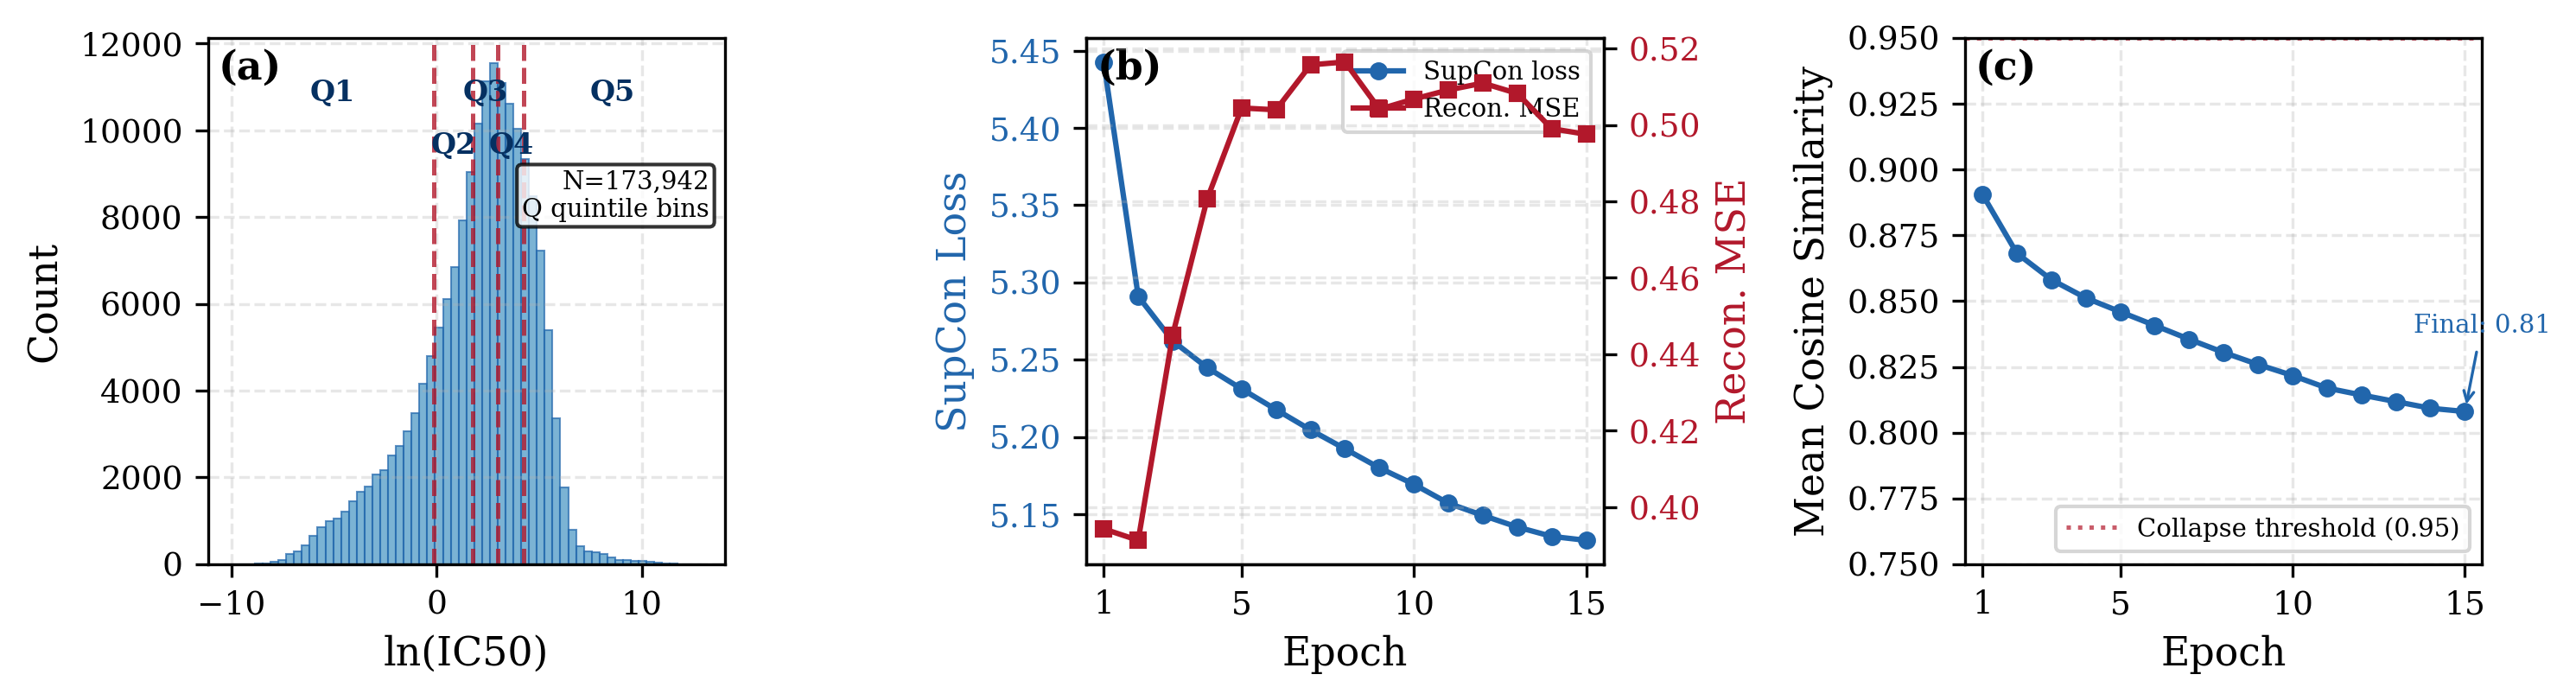

Saved: ../figures/pretraining_composite.pdf


In [6]:
"""Cell 6: Figure 5 — Pretraining Composite (3-panel).

Panel (a): IC50 distribution with quintile bins
Panel (b): SupCon + Reconstruction losses (dual y-axis)
Panel (c): Cosine similarity (collapse monitoring)
"""

# Load training history
with open(BASE_DIR / 'reports/training_history/phase3_history.json') as f:
    p3 = json.load(f)

# Load IC50 data
ic50_csv = BASE_DIR / 'data/ic50_data.csv'
df = pd.read_csv(ic50_csv)
df = df.drop_duplicates(subset=['cellline_id', 'drug_id'])

# Find IC50 column
ic50_col = None
for col in df.columns:
    if 'ic50' in col.lower() or 'ln_ic50' in col.lower():
        ic50_col = col
        break
if ic50_col is None:
    for col in reversed(df.columns):
        if df[col].dtype in [np.float64, np.float32, np.int64]:
            ic50_col = col
            break

ic50_values = df[ic50_col].dropna().values
quintiles = np.percentile(ic50_values, [20, 40, 60, 80])
print(f"IC50 samples after dedup: N={len(ic50_values):,}")
print(f"Using column: {ic50_col}")

fig, axes = plt.subplots(1, 3, figsize=(10, 2.8))

# Panel (a): IC50 distribution with quintile boundaries
ax = axes[0]
ax.hist(ic50_values, bins=60, color='#4393c3', alpha=0.7,
        edgecolor='#2166ac', linewidth=0.5)
quintile_labels = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']
boundaries = [ic50_values.min()] + list(quintiles) + [ic50_values.max()]
for i, q in enumerate(quintiles):
    ax.axvline(x=q, color=C_RED, linestyle='--', linewidth=1.2, alpha=0.8)
# Stagger Q label heights
y_max = ax.get_ylim()[1]
q_heights = [0.88, 0.78, 0.88, 0.78, 0.88]
for i in range(5):
    mid = (boundaries[i] + boundaries[i+1]) / 2
    ax.text(mid, y_max * q_heights[i], quintile_labels[i],
            fontsize=8, ha='center', color=C_DARK_BLUE, fontweight='bold')
ax.set_xlabel('ln(IC50)')
ax.set_ylabel('Count')
ax.text(0.02, 0.98, '(a)', transform=ax.transAxes, fontsize=11,
        fontweight='bold', va='top')
ax.text(0.97, 0.75, f'N={len(ic50_values):,}\nQ quintile bins',
        transform=ax.transAxes, fontsize=7, ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

# Panel (b): DR-A training losses (dual y-axis)
ax = axes[1]
ax2 = ax.twinx()
epochs = range(1, len(p3['contrastive_loss']) + 1)

l1, = ax.plot(epochs, p3['contrastive_loss'], 'o-', color=C_BLUE,
               markersize=4, linewidth=1.5, label='SupCon loss')
ax.set_ylabel('SupCon Loss', color=C_BLUE)
ax.tick_params(axis='y', labelcolor=C_BLUE)
ax.set_xlabel('Epoch')

l2, = ax2.plot(epochs, p3['recon_loss'], 's-', color=C_RED,
                markersize=4, linewidth=1.5, label='Recon. MSE')
ax2.set_ylabel('Recon. MSE', color=C_RED)
ax2.tick_params(axis='y', labelcolor=C_RED)

ax.legend([l1, l2], ['SupCon loss', 'Recon. MSE'], loc='upper right', fontsize=7)
ax.text(0.02, 0.98, '(b)', transform=ax.transAxes, fontsize=11,
        fontweight='bold', va='top')
ax.set_xlim(0.5, 15.5)
ax.set_xticks([1, 5, 10, 15])

# Panel (c): Cosine similarity
ax = axes[2]
ax.plot(epochs, p3['mean_cosine_sim'], 'o-', color=C_BLUE, markersize=4, linewidth=1.5)
ax.axhline(y=0.95, color=C_RED, linestyle=':', linewidth=1.2, alpha=0.7,
           label='Collapse threshold (0.95)')
final_cosine = p3['mean_cosine_sim'][-1]
ax.annotate(f'Final: {final_cosine:.2f}', xy=(15, final_cosine),
            xytext=(13.5, final_cosine + 0.03),
            fontsize=7, color=C_BLUE,
            arrowprops=dict(arrowstyle='->', color=C_BLUE, lw=0.8))
ax.set_xlabel('Epoch')
ax.set_ylabel('Mean Cosine Similarity')
ax.text(0.02, 0.98, '(c)', transform=ax.transAxes, fontsize=11,
        fontweight='bold', va='top')
ax.set_xlim(0.5, 15.5)
ax.set_ylim(0.75, 0.95)
ax.set_xticks([1, 5, 10, 15])
ax.legend(loc='lower right', fontsize=7)

plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'pretraining_composite.pdf'))
plt.savefig(str(FIGURES_DIR / 'pretraining_composite.png'))
plt.show()
print(f"Saved: {FIGURES_DIR / 'pretraining_composite.pdf'}")

## Summary of Generated Figures

| Fig | File | Description |
|-----|------|-------------|
| 1 | `figures/architecture.pdf` | Full pipeline architecture diagram |
| 2 | `figures/tsne_combined.pdf` | t-SNE comparison: Random Init → CLRNA → DR-A (colored by IC50 quintile) |
| 3 | `figures/generalization_hierarchy.pdf` | Generalization hierarchy: Random → NCC (592) → NCC (998) → Leak-free → NCD |
| 4 | `figures/figure4_components_transferability.pdf` | Component contributions + XGBoost transferability |
| 5 | `figures/pretraining_composite.pdf` | IC50 distribution + DR-A losses + cosine similarity |

All figures saved in both PDF (vector) and PNG (raster, 300 DPI) formats.